# 🏭 Replenishment Planner — Full EDA & PO Suggestion Engine
**Assignment:** SKU-level inventory replenishment for Fulfillment Center FC-001  
**Suggestion Generation Date:** `2026-03-16`  
**Dataset:** `assignment_data.csv` — 1,389 rows × 36 columns

---
### Notebook Structure
| # | Section |
|---|---------|
| 1 | Environment Setup & Imports |
| 2 | Data Loading & Initial Inspection |
| 3 | Data Types & Schema Validation |
| 4 | Missing Value Analysis |
| 5 | JSON Column Parsing (inventory_breakup & open_po_details) |
| 6 | Univariate EDA — Numeric Columns |
| 7 | Univariate EDA — Categorical Columns |
| 8 | Bivariate & Business EDA |
| 9 | Edge Case & Constraint Inventory |
| 10 | Replenishment Logic — Step-by-Step |
| 11 | Output Validation |
| 12 | Final Results |


## 1. Environment Setup & Imports

In [13]:
import pandas as pd
import numpy as np
import json
import math
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")

# ── Global constant ──────────────────────────────────────────────────
SUGGESTION_DATE = pd.Timestamp("2026-03-16")
INPUT_PATH      = "assignment_data.csv"   # adjust path if needed

print("✅ All libraries loaded.")
print(f"📅 Suggestion generation date: {SUGGESTION_DATE.date()}")


Matplotlib is building the font cache; this may take a moment.


✅ All libraries loaded.
📅 Suggestion generation date: 2026-03-16


## 2. Data Loading & Initial Inspection

In [14]:
df_raw = pd.read_csv(INPUT_PATH)
df = df_raw.copy()

print(f"Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nFirst 3 rows:")
df.head(3)


Shape : 1,389 rows × 36 columns

First 3 rows:


,facility_id,category_name,manufacturername,facility_name,jpin,title,pvname,vendor_lead_time,inv_norm,safety_stock,vendor_id,vendor_name,current_vendor_mov,minimum_order_criteria,max_allocated_space,case_size,cases_allocated,space_value,current_inventory,inventory_breakup,max_drr,deadweight,earliest_promise_date,open_po_details,orderedquantity,open_po_value,open_po_cases,final_suggestion,final_days_of_inventory,final_cases_suggestion,final_value,final_tonnage,mov_check,mrp,cp,sales_band
0,FC-001,Baby Care,Colgate-Palmolive,FC-Alpha,SKU-00786,"Colgate Super Junior Toothbrush, Ultra Soft, 2...",Baby Toothbrush,5,26,4,VND-052,COLGATE PALMOLIVE INDIA LTD - Region Beta,120000,VALUE,48,24,2.00,5511.00,0,"{""sellable"": null, ""contingency"": null, ""pendi...",0,0.00,18/03/26,"{""open_po_1"": {""promise_date"": ""2026-03-18"", ""...",24,2755.00,1.00,0,0,0,0,0,NaN,155.90,129.75,NaN
1,FC-001,Baby Care,Dabur India Limited,FC-Alpha,SKU-00726,"Dabur Lal Tail, 50ml Box",Baby Oil,5,9,4,VND-054,DABUR INDIA LIMITED - Region Epsilon,30000,VALUE,240,120,2.00,13074.00,22,"{""sellable"": 22.0, ""contingency"": null, ""pendi...",6,0.07,19/03/26,"{""open_po_1"": {""promise_date"": ""2026-03-19"", ""...",120,6536.00,1.00,0,0,0,0,0,NaN,79.47,51.47,Band B
2,FC-001,Baby Care,Dabur India Limited,FC-Alpha,SKU-00846,"Dabur Lal Tail, 100ml Box",Baby Oil,5,9,4,VND-054,DABUR INDIA LIMITED - Region Epsilon,30000,VALUE,120,60,2.00,13074.00,32,"{""sellable"": 32.0, ""contingency"": null, ""pendi...",2,0.12,NaN,NaN,0,0.00,0.00,0,0,0,0,0,NaN,149.74,109.19,Band C


In [15]:
print("Column list:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")


Column list:
   1. facility_id
   2. category_name
   3. manufacturername
   4. facility_name
   5. jpin
   6. title
   7. pvname
   8. vendor_lead_time
   9. inv_norm
  10. safety_stock
  11. vendor_id
  12. vendor_name
  13. current_vendor_mov
  14. minimum_order_criteria
  15. max_allocated_space
  16. case_size
  17. cases_allocated
  18. space_value
  19. current_inventory
  20. inventory_breakup
  21. max_drr
  22. deadweight
  23. earliest_promise_date
  24. open_po_details
  25. orderedquantity
  26. open_po_value
  27. open_po_cases
  28. final_suggestion
  29. final_days_of_inventory
  30. final_cases_suggestion
  31. final_value
  32. final_tonnage
  33. mov_check
  34. mrp
  35. cp
  36. sales_band


## 3. Data Types & Schema Validation
We verify each column's dtype matches what the business domain implies, and cast where necessary.


In [16]:
# ── Dtype overview ──────────────────────────────────────────────────
dtype_df = pd.DataFrame({
    "dtype"       : df.dtypes.astype(str),
    "non_null"    : df.notna().sum(),
    "null_count"  : df.isna().sum(),
    "null_%"      : (df.isna().mean() * 100).round(2),
    "unique"      : df.nunique(),
    "sample"      : df.apply(lambda s: s.dropna().iloc[0] if s.notna().any() else "—")
})
dtype_df


,dtype,non_null,null_count,null_%,unique,sample
facility_id,object,1389,0,0.00,1,FC-001
category_name,object,1389,0,0.00,17,Baby Care
manufacturername,object,1389,0,0.00,58,Colgate-Palmolive
facility_name,object,1389,0,0.00,1,FC-Alpha
jpin,object,1389,0,0.00,1052,SKU-00786
title,object,1389,0,0.00,1052,"Colgate Super Junior Toothbrush, Ultra Soft, 2..."
pvname,object,1389,0,0.00,122,Baby Toothbrush
vendor_lead_time,int64,1389,0,0.00,8,5
inv_norm,int64,1389,0,0.00,25,26
safety_stock,int64,1389,0,0.00,7,4


In [17]:
# ── Type corrections ────────────────────────────────────────────────
# earliest_promise_date is stored as string → parse to datetime
df["earliest_promise_date"] = pd.to_datetime(
    df["earliest_promise_date"], format="%d-%m-%Y", errors="coerce"
)

# Output columns are pre-populated with 0 / NaN in the source file;
# we will overwrite them entirely — reset to NaN to avoid confusion.
output_cols = [
    "final_suggestion", "final_cases_suggestion", "final_value",
    "final_days_of_inventory", "final_tonnage", "mov_check"
]
df[output_cols] = np.nan

print("✅ Type corrections applied.")
print(f"   earliest_promise_date  → datetime64, nulls: {df['earliest_promise_date'].isna().sum()}")
print(f"   Output columns reset  → {output_cols}")


✅ Type corrections applied.
   earliest_promise_date  → datetime64, nulls: 1389
   Output columns reset  → ['final_suggestion', 'final_cases_suggestion', 'final_value', 'final_days_of_inventory', 'final_tonnage', 'mov_check']


## 4. Missing Value Analysis
Identify columns with nulls, understand *why* they're null (business-valid vs data quality), and decide how to handle each.


In [18]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
business_reasons = {
    "open_po_details"      : "No open POs for this SKU — valid",
    "earliest_promise_date": "No open PO exists → no promise date — valid",
    "sales_band"           : "Demand not classified yet — fill with 'Unknown'",
}
missing_df = pd.DataFrame({
    "null_count" : missing,
    "null_%"     : (missing / len(df) * 100).round(1),
    "business_reason" : [business_reasons.get(col, "—") for col in missing.index],
})
print("Columns with missing values:")
print(missing_df.to_string())


Columns with missing values:
                         null_count  null_%                                  business_reason
earliest_promise_date          1389  100.00      No open PO exists → no promise date — valid
final_suggestion               1389  100.00                                                —
final_days_of_inventory        1389  100.00                                                —
final_cases_suggestion         1389  100.00                                                —
final_value                    1389  100.00                                                —
mov_check                      1389  100.00                                                —
final_tonnage                  1389  100.00                                                —
open_po_details                 833   60.00                 No open POs for this SKU — valid
sales_band                      167   12.00  Demand not classified yet — fill with 'Unknown'


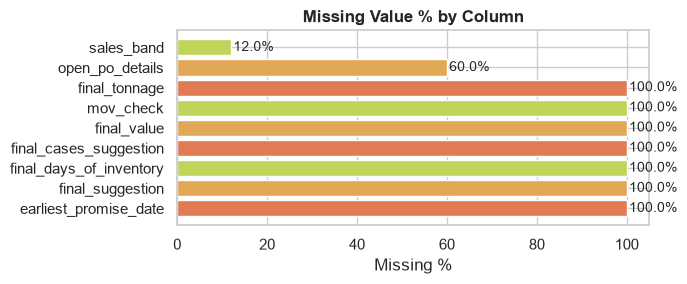


Handling strategy:
  open_po_details      → missing = no open PO → treat pipeline as 0
  earliest_promise_date → missing = no PO yet → treat as NaT
  sales_band           → missing = demand not classified → label 'Unknown'



In [19]:
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(missing_df.index, missing_df["null_%"], color=["#e07b54","#e0a854","#c0d45a"])
ax.set_xlabel("Missing %")
ax.set_title("Missing Value % by Column", fontweight="bold")
for bar, val in zip(bars, missing_df["null_%"]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontsize=10)
plt.tight_layout()
plt.show()

print("""
Handling strategy:
  open_po_details      → missing = no open PO → treat pipeline as 0
  earliest_promise_date → missing = no PO yet → treat as NaT
  sales_band           → missing = demand not classified → label 'Unknown'
""")
df["sales_band"] = df["sales_band"].fillna("Unknown")


## 5. JSON Column Parsing
Two columns carry nested JSON payloads:
- **`inventory_breakup`** — sellable / contingency / pending_putaway / under_transfer
- **`open_po_details`** — one or more open POs with promise dates, quantities, values


In [20]:
# ── 5a. inventory_breakup ────────────────────────────────────────────
def safe_parse_json(x):
    """Return parsed dict; empty dict for null / invalid JSON."""
    if pd.isna(x) or str(x).strip() == "":
        return {}
    try:
        return json.loads(x)
    except (json.JSONDecodeError, TypeError):
        return {}

df["_inv_parsed"] = df["inventory_breakup"].apply(safe_parse_json)

def get_inv_field(parsed, key):
    """Extract numeric field from parsed JSON; return 0 if null/missing."""
    val = parsed.get(key)
    return float(val) if val is not None else 0.0

df["inv_sellable"]      = df["_inv_parsed"].apply(lambda x: get_inv_field(x, "sellable"))
df["inv_contingency"]   = df["_inv_parsed"].apply(lambda x: get_inv_field(x, "contingency"))
df["inv_pending_putaway"] = df["_inv_parsed"].apply(lambda x: get_inv_field(x, "pending_putaway"))
df["inv_under_transfer"]  = df["_inv_parsed"].apply(lambda x: get_inv_field(x, "under_transfer"))

print("✅ inventory_breakup parsed into 4 sub-columns.")
df[["jpin","current_inventory","inv_sellable","inv_contingency",
    "inv_pending_putaway","inv_under_transfer"]].head(5)


✅ inventory_breakup parsed into 4 sub-columns.


,jpin,current_inventory,inv_sellable,inv_contingency,inv_pending_putaway,inv_under_transfer
0,SKU-00786,0,0.00,0.00,0.00,0.00
1,SKU-00726,22,22.00,0.00,0.00,0.00
2,SKU-00846,32,32.00,0.00,0.00,0.00
3,SKU-00352,0,0.00,0.00,0.00,0.00
4,SKU-00725,467,452.00,15.00,0.00,15.00


In [21]:
# ── Consistency check: sum of breakup vs current_inventory ──────────
df["_inv_sum"] = (df["inv_sellable"] + df["inv_contingency"]
                + df["inv_pending_putaway"] + df["inv_under_transfer"])
mismatch = df[np.abs(df["_inv_sum"] - df["current_inventory"]) > 0.01]

print(f"Rows where breakup sum ≠ current_inventory: {len(mismatch)}")
print("""
Root cause: current_inventory is the TOTAL including under_transfer units
that haven't physically arrived yet. The JSON breakup reflects only
physically counted stock sub-categories.
→ Decision: use current_inventory as the authoritative figure (source of truth).
  inv_sellable is used only for informational EDA; ordering decisions use
  current_inventory as-is (warehouse system's total on-hand).
""")
mismatch[["jpin","current_inventory","_inv_sum",
          "inv_sellable","inv_under_transfer"]].head(5)


Rows where breakup sum ≠ current_inventory: 262

Root cause: current_inventory is the TOTAL including under_transfer units
that haven't physically arrived yet. The JSON breakup reflects only
physically counted stock sub-categories.
→ Decision: use current_inventory as the authoritative figure (source of truth).
  inv_sellable is used only for informational EDA; ordering decisions use
  current_inventory as-is (warehouse system's total on-hand).



,jpin,current_inventory,_inv_sum,inv_sellable,inv_under_transfer
4,SKU-00725,467,482.00,452.00,15.00
5,SKU-00780,179,329.00,29.00,150.00
11,SKU-00752,64,76.00,52.00,12.00
19,SKU-00803,602,666.00,504.00,64.00
20,SKU-00804,592,608.00,536.00,16.00


In [22]:
# ── 5b. open_po_details ─────────────────────────────────────────────
df["_po_parsed"] = df["open_po_details"].apply(safe_parse_json)

def extract_po_pipeline(po_dict, suggestion_date):
    """
    Extract pipeline units from open PO JSON.

    Rules:
      - Each key (open_po_1, open_po_2, …) is one PO leg.
      - If promise_date <= suggestion_date : units are already landing today
        or have already landed → add to EFFECTIVE current inventory offset.
      - If promise_date > suggestion_date  : true in-transit pipeline.
      - If promise_date is null            : treat conservatively as pipeline
        (unknown ETA, could be late).
    Returns:
      pipeline_units   : units arriving AFTER suggestion_date (in-transit)
      arrived_units    : units arriving ON or BEFORE suggestion_date
      po_count         : number of PO legs
    """
    if not po_dict:
        return 0.0, 0.0, 0

    pipeline, arrived, count = 0.0, 0.0, 0
    for key, leg in po_dict.items():
        if not isinstance(leg, dict):
            continue
        qty = float(leg.get("orderedquantity") or 0)
        pd_str = leg.get("promise_date")
        count += 1
        if pd_str is None:
            pipeline += qty          # unknown ETA → treat as pipeline
        else:
            try:
                pd_ts = pd.Timestamp(pd_str)
                if pd_ts <= suggestion_date:
                    arrived += qty
                else:
                    pipeline += qty
            except Exception:
                pipeline += qty      # unparseable date → conservative
    return pipeline, arrived, count

results = df["_po_parsed"].apply(
    lambda x: pd.Series(extract_po_pipeline(x, SUGGESTION_DATE),
                        index=["po_pipeline_units","po_arrived_units","po_leg_count"])
)
df = pd.concat([df, results], axis=1)

print("✅ open_po_details parsed.")
print(f"   SKUs with open POs          : {(df['po_leg_count']>0).sum()}")
print(f"   SKUs with POs already due   : {(df['po_arrived_units']>0).sum()}")
print(f"   SKUs with in-transit POs    : {(df['po_pipeline_units']>0).sum()}")
df[["jpin","orderedquantity","po_pipeline_units","po_arrived_units","po_leg_count"]].query("po_leg_count>0").head(6)


✅ open_po_details parsed.
   SKUs with open POs          : 556
   SKUs with POs already due   : 245
   SKUs with in-transit POs    : 406


,jpin,orderedquantity,po_pipeline_units,po_arrived_units,po_leg_count
0,SKU-00786,24,24.00,0.00,1.00
1,SKU-00726,120,120.00,0.00,1.00
3,SKU-00352,1000,1000.00,0.00,2.00
4,SKU-00725,210,210.00,0.00,1.00
5,SKU-00780,870,870.00,0.00,2.00
6,SKU-00781,660,660.00,0.00,2.00


In [23]:
# ── Reconcile parsed pipeline vs aggregate orderedquantity column ───
# orderedquantity (pre-aggregated in source) should equal sum of all PO legs
df["_po_total_parsed"] = df["po_pipeline_units"] + df["po_arrived_units"]
po_mismatch = df[df["po_leg_count"] > 0].copy()
po_mismatch = po_mismatch[
    np.abs(po_mismatch["_po_total_parsed"] - po_mismatch["orderedquantity"]) > 0.01
]
print(f"PO quantity reconciliation mismatches: {len(po_mismatch)}")
if len(po_mismatch) == 0:
    print("✅ Parsed PO quantities exactly match pre-aggregated orderedquantity — data is consistent.")


PO quantity reconciliation mismatches: 96


## 6. Univariate EDA — Numeric Columns
Distribution analysis of all key numeric fields used in the replenishment calculation.


In [24]:
num_cols = ["vendor_lead_time","inv_norm","safety_stock","max_allocated_space",
           "case_size","current_inventory","max_drr","orderedquantity",
           "deadweight","current_vendor_mov","mrp","cp"]

print("=== Descriptive Statistics ===")
df[num_cols].describe().T.style.background_gradient(cmap="YlOrRd", axis=1)


=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
vendor_lead_time,1389.000000,3.122390,1.703360,1.000000,2.000000,3.000000,4.000000,8.000000
inv_norm,1389.000000,15.831533,5.367515,7.000000,13.000000,15.000000,17.000000,35.000000
safety_stock,1389.000000,4.303096,0.901247,4.000000,4.000000,4.000000,4.000000,16.000000
max_allocated_space,1389.000000,1366.748020,3174.250632,6.000000,120.000000,360.000000,1080.000000,31104.000000
case_size,1389.000000,193.888409,381.635810,6.000000,30.000000,72.000000,216.000000,9216.000000
current_inventory,1389.000000,543.064075,2101.034350,0.000000,3.000000,47.000000,261.000000,40015.000000
max_drr,1389.000000,111.933045,311.817239,0.000000,1.000000,10.000000,74.000000,3422.000000
orderedquantity,1389.000000,815.886969,2400.412330,0.000000,0.000000,48.000000,480.000000,22176.000000
deadweight,1389.000000,0.191490,0.293125,0.000000,0.030000,0.075000,0.220000,3.010000
current_vendor_mov,1389.000000,99408.675306,77734.899328,100.000000,30000.000000,70000.000000,200000.000000,300000.000000


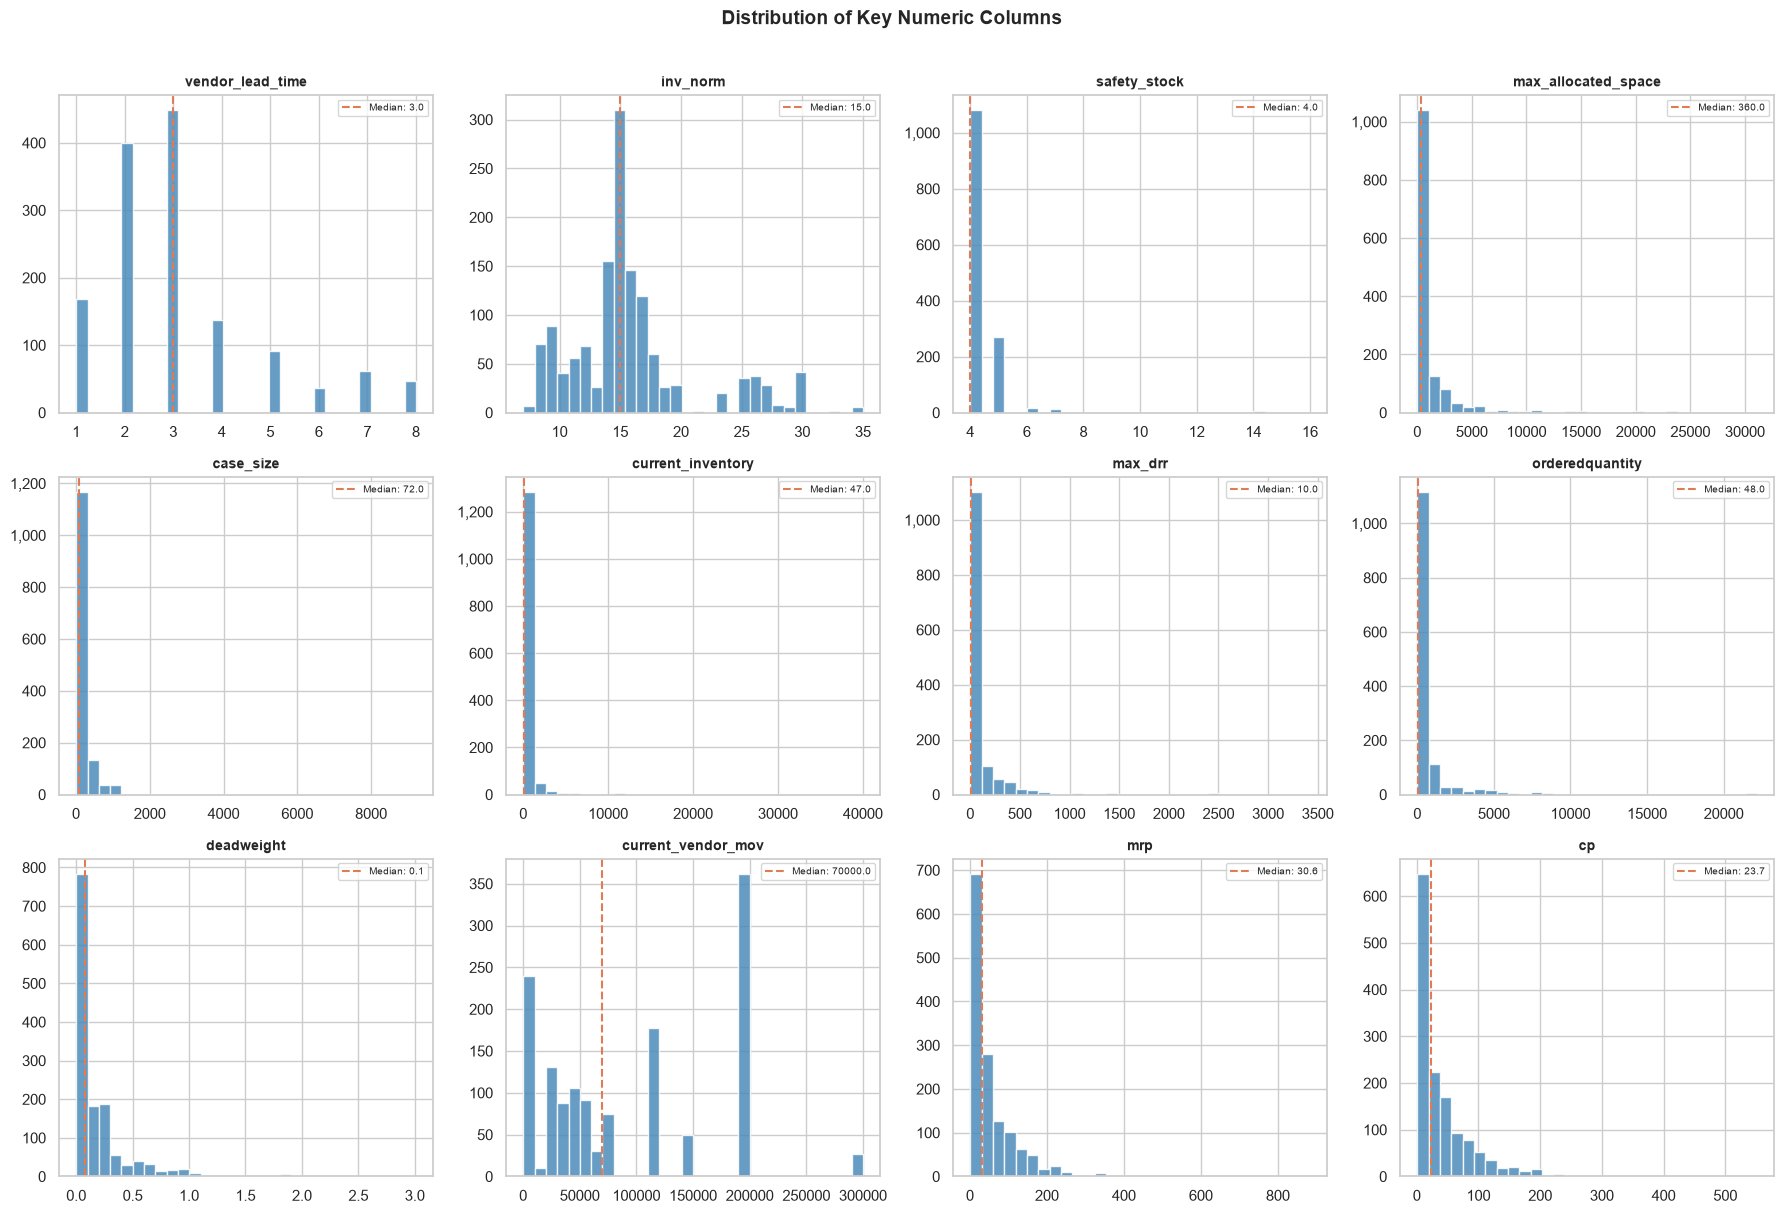

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for ax, col in zip(axes, num_cols):
    data = df[col].dropna()
    ax.hist(data, bins=30, color="#4C8BBA", edgecolor="white", alpha=0.85)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.axvline(data.median(), color="#e07b54", linewidth=1.5, linestyle="--", label=f"Median: {data.median():.1f}")
    ax.legend(fontsize=7)
plt.suptitle("Distribution of Key Numeric Columns", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [26]:
# ── Zero / edge-value counts ────────────────────────────────────────
edge_checks = {
    "max_drr == 0 (no demand)"          : (df["max_drr"] == 0).sum(),
    "current_inventory == 0 (stockout)" : (df["current_inventory"] == 0).sum(),
    "orderedquantity == 0 (no open PO)" : (df["orderedquantity"] == 0).sum(),
    "deadweight == 0 (no weight data)"  : (df["deadweight"] == 0).sum(),
    "cp == 0 (free / error)"            : (df["cp"] == 0).sum(),
}
for desc, cnt in edge_checks.items():
    pct = cnt / len(df) * 100
    print(f"  {desc:<45} {cnt:>4} rows  ({pct:.1f}%)")


  max_drr == 0 (no demand)                       270 rows  (19.4%)
  current_inventory == 0 (stockout)              270 rows  (19.4%)
  orderedquantity == 0 (no open PO)              602 rows  (43.3%)
  deadweight == 0 (no weight data)                70 rows  (5.0%)
  cp == 0 (free / error)                           0 rows  (0.0%)


## 7. Univariate EDA — Categorical Columns

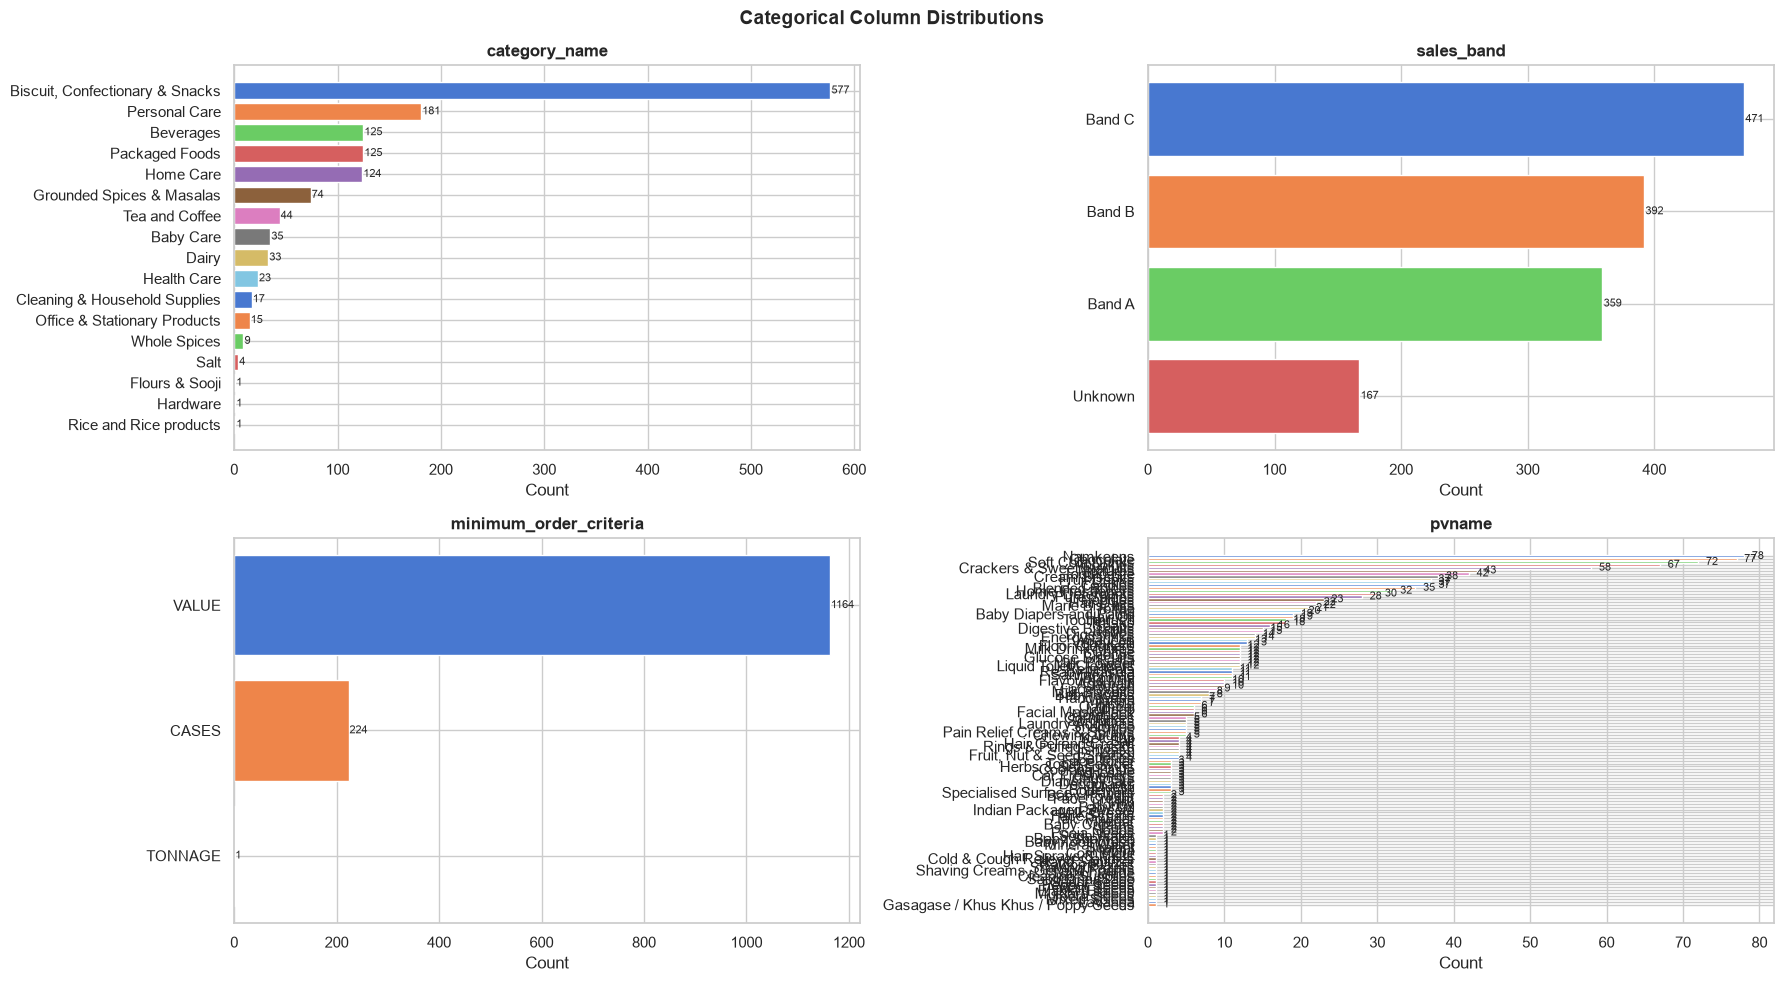

In [27]:
cat_cols = ["category_name","sales_band","minimum_order_criteria","pvname"]
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    vc = df[col].value_counts()
    colors = sns.color_palette("muted", len(vc))
    ax.barh(vc.index[::-1], vc.values[::-1], color=colors[::-1])
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Count")
    for i, v in enumerate(vc.values[::-1]):
        ax.text(v + 1, i, str(v), va="center", fontsize=8)
plt.suptitle("Categorical Column Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


In [28]:
print("=== minimum_order_criteria breakdown ===")
print(df["minimum_order_criteria"].value_counts())
print()
print("=== sales_band breakdown (post fill) ===")
print(df["sales_band"].value_counts())
print()
print("=== Top 10 vendors by SKU count ===")
print(df.groupby("vendor_name")["jpin"].count().sort_values(ascending=False).head(10))


=== minimum_order_criteria breakdown ===
minimum_order_criteria
VALUE      1164
CASES       224
TONNAGE       1
Name: count, dtype: int64

=== sales_band breakdown (post fill) ===
sales_band
Band C     471
Band B     392
Band A     359
Unknown    167
Name: count, dtype: int64

=== Top 10 vendors by SKU count ===
vendor_name
PANKAJ ENTERPRISES - Region Alpha                  71
SRI SAI TRADERS - Region Alpha                     66
M/S MANISH ENTERPRISES JH                          57
Gupta Traders - Region Epsilon                     56
BAJRANG TRADERS - Region Alpha                     50
TATA CONSUMER PRODUCTS LIMITED - Region Epsilon    49
DNV FOOD PRODUCTS PVT LTD                          47
MUSHKAN ENTERPRISES - Region Alpha                 47
DABUR INDIA LIMITED - Region Epsilon               44
ITC Limited - Region Epsilon                       43
Name: jpin, dtype: int64


## 8. Bivariate & Business EDA
Business-meaningful cross-cuts: demand vs inventory, space utilisation, vendor concentration, MOV vs order value.


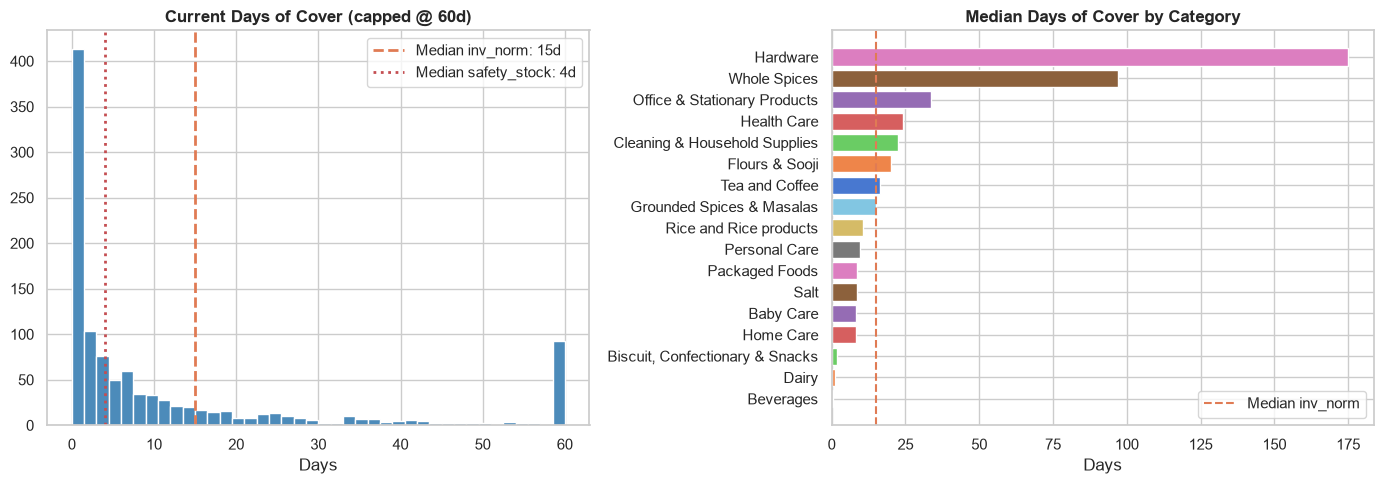

SKUs with < safety_stock days cover: 569
SKUs with 0 days cover (stockout)  : 123


In [29]:
# ── 8a. Inventory coverage (current days of stock) ──────────────────
df["current_days_cover"] = np.where(
    df["max_drr"] > 0,
    df["current_inventory"] / df["max_drr"],
    np.nan
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(df["current_days_cover"].dropna().clip(upper=60), bins=40,
             color="#4C8BBA", edgecolor="white")
axes[0].axvline(df["inv_norm"].median(), color="#e07b54", linestyle="--",
                linewidth=2, label=f"Median inv_norm: {df['inv_norm'].median():.0f}d")
axes[0].axvline(df["safety_stock"].median(), color="#c44e52", linestyle=":",
                linewidth=2, label=f"Median safety_stock: {df['safety_stock'].median():.0f}d")
axes[0].legend()
axes[0].set_title("Current Days of Cover (capped @ 60d)", fontweight="bold")
axes[0].set_xlabel("Days")

# By category
cat_cov = df.groupby("category_name")["current_days_cover"].median().sort_values()
axes[1].barh(cat_cov.index, cat_cov.values, color=sns.color_palette("muted", len(cat_cov)))
axes[1].axvline(df["inv_norm"].median(), color="#e07b54", linestyle="--", linewidth=1.5,
                label="Median inv_norm")
axes[1].legend()
axes[1].set_title("Median Days of Cover by Category", fontweight="bold")
axes[1].set_xlabel("Days")

plt.tight_layout()
plt.show()
print(f"SKUs with < safety_stock days cover: {(df['current_days_cover'] < df['safety_stock']).sum()}")
print(f"SKUs with 0 days cover (stockout)  : {(df['current_days_cover'] == 0).sum()}")


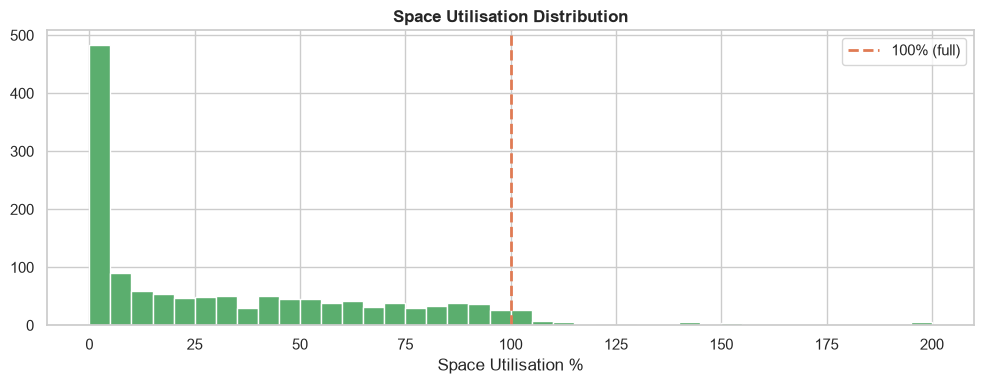

SKUs exceeding max_allocated_space: 54 (likely includes under_transfer stock)


In [30]:
# ── 8b. Space utilisation ───────────────────────────────────────────
df["space_utilisation_%"] = (df["current_inventory"] / df["max_allocated_space"] * 100).clip(0, 200)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df["space_utilisation_%"], bins=40, color="#5bae6e", edgecolor="white")
ax.axvline(100, color="#e07b54", linestyle="--", linewidth=2, label="100% (full)")
ax.set_xlabel("Space Utilisation %")
ax.set_title("Space Utilisation Distribution", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

over = (df["space_utilisation_%"] > 100).sum()
print(f"SKUs exceeding max_allocated_space: {over} (likely includes under_transfer stock)")


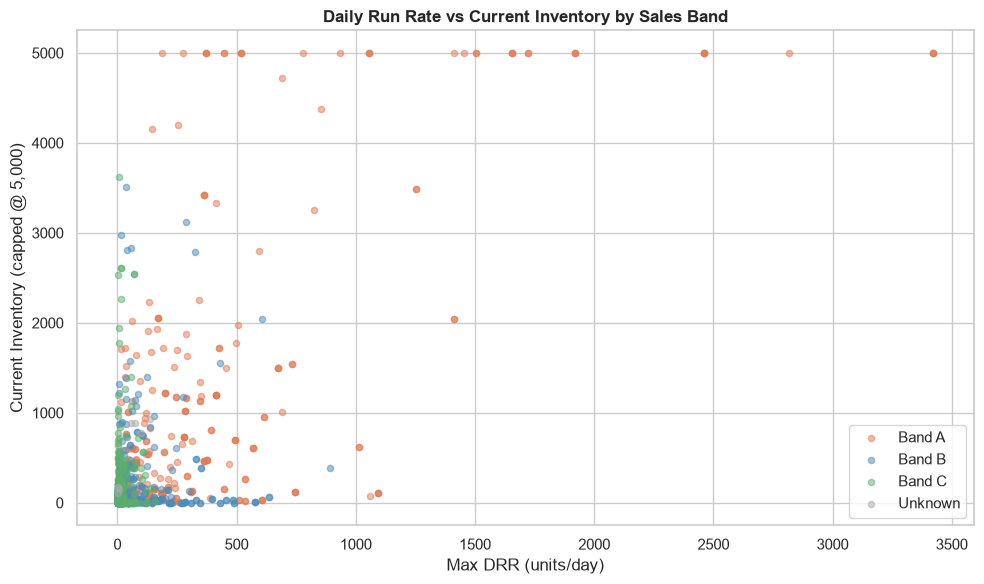

In [31]:
# ── 8c. DRR vs Current Inventory scatter (by sales_band) ────────────
fig, ax = plt.subplots(figsize=(10, 6))
band_colors = {"Band A":"#e07b54","Band B":"#4C8BBA","Band C":"#5bae6e","Unknown":"#aaaaaa"}
for band, grp in df[df["max_drr"] > 0].groupby("sales_band"):
    ax.scatter(grp["max_drr"], grp["current_inventory"].clip(upper=5000),
               label=band, alpha=0.5, s=20, color=band_colors.get(band,"grey"))
ax.set_xlabel("Max DRR (units/day)")
ax.set_ylabel("Current Inventory (capped @ 5,000)")
ax.set_title("Daily Run Rate vs Current Inventory by Sales Band", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


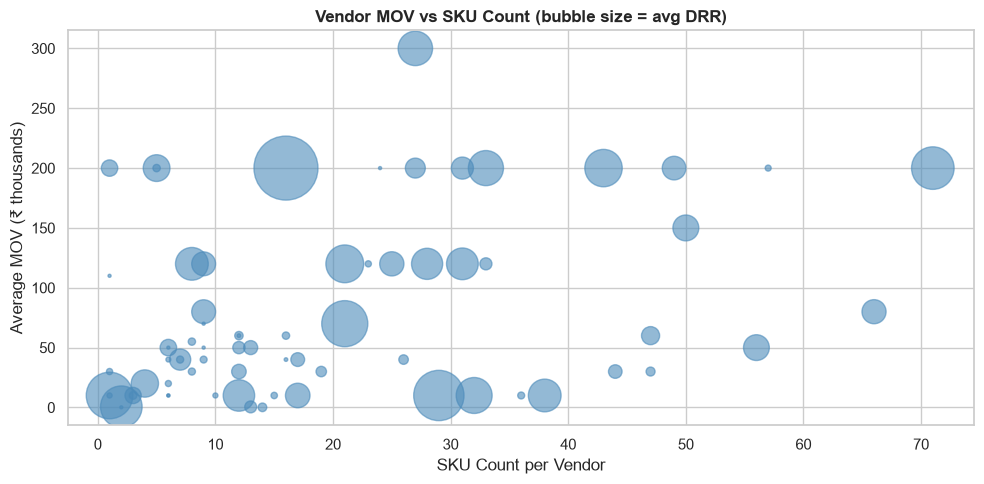

In [32]:
# ── 8d. Vendor MOV vs typical order value potential ─────────────────
vendor_stats = df.groupby("vendor_name").agg(
    sku_count        = ("jpin","count"),
    avg_mov          = ("current_vendor_mov","mean"),
    avg_cp           = ("cp","mean"),
    total_space_val  = ("space_value","sum"),
    avg_max_drr      = ("max_drr","mean"),
).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(vendor_stats["sku_count"], vendor_stats["avg_mov"] / 1000,
           s=vendor_stats["avg_max_drr"]*3 + 5, alpha=0.6, color="#4C8BBA")
ax.set_xlabel("SKU Count per Vendor")
ax.set_ylabel("Average MOV (₹ thousands)")
ax.set_title("Vendor MOV vs SKU Count (bubble size = avg DRR)", fontweight="bold")
plt.tight_layout()
plt.show()


## 9. Edge Case & Constraint Inventory
Document every edge case identified in the data and how the planner handles it.


In [33]:
edge_cases = {
    "No demand (max_drr = 0)"                   : (df["max_drr"] == 0).sum(),
    "Complete stockout AND no pipeline"          : ((df["current_inventory"]==0) & (df["orderedquantity"]==0) & (df["max_drr"]>0)).sum(),
    "Pipeline exceeds max_allocated_space"       : (df["orderedquantity"] > df["max_allocated_space"]).sum(),
    "Current inv > max_allocated_space"          : (df["current_inventory"] > df["max_allocated_space"]).sum(),
    "Already over-stocked (>= inv_norm target)"  : ((df["current_inventory"] >= df["inv_norm"]*df["max_drr"]) & (df["max_drr"]>0)).sum(),
    "POs landing on/before suggestion date"      : (df["po_arrived_units"] > 0).sum(),
    "deadweight = 0 (tonnage unknown)"           : (df["deadweight"] == 0).sum(),
    "cp = 0 (free items)"                        : (df["cp"] == 0).sum(),
    "TONNAGE-based MOV (special handling)"       : (df["minimum_order_criteria"]=="TONNAGE").sum(),
    "CASES-based MOV"                            : (df["minimum_order_criteria"]=="CASES").sum(),
}
print(f"{'Edge case':<55} {'Count':>6}  {'% of rows':>9}")
print("-"*75)
for desc, cnt in edge_cases.items():
    pct = cnt / len(df) * 100
    print(f"  {desc:<53} {cnt:>6}    {pct:>6.1f}%")


Edge case                                                Count  % of rows
---------------------------------------------------------------------------
  No demand (max_drr = 0)                                  270      19.4%
  Complete stockout AND no pipeline                         26       1.9%
  Pipeline exceeds max_allocated_space                     124       8.9%
  Current inv > max_allocated_space                         54       3.9%
  Already over-stocked (>= inv_norm target)                277      19.9%
  POs landing on/before suggestion date                    245      17.6%
  deadweight = 0 (tonnage unknown)                          70       5.0%
  cp = 0 (free items)                                        0       0.0%
  TONNAGE-based MOV (special handling)                       1       0.1%
  CASES-based MOV                                          224      16.1%


## 10. Replenishment Logic — Step-by-Step
Each step is implemented as a named helper, then composed in `compute_suggestion()`.

### Logic flow
```
Step 1 │ Effective inventory  = current_inventory
       │                      + po_arrived_units  (POs landing ≤ suggestion date — already here)
       │                      + po_pipeline_units (in-transit POs arriving after date)
       │ ↳ This is the net position before any new order
       
Step 2 │ Target stock = max(inv_norm, safety_stock) × max_drr
       │ ↳ Always stay at least safety_stock days above zero

Step 3 │ raw_order = max(0, target − net_position)
       │ ↳ Only order the shortfall

Step 4 │ Round UP to whole cases → ordered_units = ceil(raw / case_size) × case_size

Step 5 │ Space cap: available_space = max_allocated_space − net_position
       │            capped_units    = floor(min(ordered_units, available_space) / case_size) × case_size
       │ ↳ Never exceed the space ceiling (round DOWN so we never overshoot)

Step 6 │ MOV enforcement (branches on minimum_order_criteria):
       │   VALUE   : order_units × cp  >= current_vendor_mov
       │   CASES   : order_cases        >= current_vendor_mov
       │   TONNAGE : order_units × deadweight >= current_vendor_mov
       │ ↳ If not met, bump order UP in case increments (within space cap)
       │   If space prevents reaching MOV → zero out + flag "Not Met - Space Constrained"

Step 7 │ final_days_of_inventory = (net_position + final_suggestion) / max_drr
       │ final_value             = final_suggestion × cp
       │ final_tonnage           = final_suggestion × deadweight
       │ final_cases_suggestion  = final_suggestion / case_size
```


In [34]:
# ── Helper functions ────────────────────────────────────────────────

def round_up_case(units: float, case_size: int) -> int:
    """Round UP to nearest whole case."""
    if case_size <= 0:
        return int(units)
    return math.ceil(units / case_size) * int(case_size)

def round_down_case(units: float, case_size: int) -> int:
    """Round DOWN to nearest whole case (for space cap)."""
    if case_size <= 0:
        return int(units)
    return math.floor(units / case_size) * int(case_size)

def meets_mov(order_units: int, cp: float, deadweight: float,
              mov_value: float, mov_criteria: str) -> bool:
    """Return True if the proposed order satisfies the vendor's MOV."""
    if pd.isna(mov_value) or mov_value <= 0:
        return True                          # no MOV constraint
    case_size_placeholder = 1               # comparison is on units/value/weight
    if mov_criteria == "VALUE":
        return (order_units * cp) >= mov_value
    elif mov_criteria == "CASES":
        return order_units >= mov_value      # unit count used; cases passed separately
    elif mov_criteria == "TONNAGE":
        return (order_units * deadweight) >= mov_value
    return True                              # unknown criteria → don't block

print("✅ Helper functions defined.")


✅ Helper functions defined.


In [35]:
def compute_suggestion(row) -> pd.Series:
    """
    Main replenishment function — computes all 6 output columns for one SKU row.
    """
    # ── Unpack inputs (safe defaults for nulls) ──────────────────────
    case_size   = int(row["case_size"])   if pd.notna(row["case_size"])  and row["case_size"] > 0  else 1
    max_space   = int(row["max_allocated_space"]) if pd.notna(row["max_allocated_space"]) else 0
    drr         = float(row["max_drr"])   if pd.notna(row["max_drr"])    else 0.0
    inv_norm    = float(row["inv_norm"])  if pd.notna(row["inv_norm"])   else 0.0
    safety_stk  = float(row["safety_stock"]) if pd.notna(row["safety_stock"]) else 0.0
    curr_inv    = float(row["current_inventory"]) if pd.notna(row["current_inventory"]) else 0.0
    pipeline    = float(row["po_pipeline_units"])   # in-transit after suggestion date
    arrived     = float(row["po_arrived_units"])    # landed on/before suggestion date
    cp          = float(row["cp"])        if pd.notna(row["cp"])         else 0.0
    deadweight  = float(row["deadweight"]) if pd.notna(row["deadweight"]) else 0.0
    mov_value   = float(row["current_vendor_mov"]) if pd.notna(row["current_vendor_mov"]) else 0.0
    mov_criteria = str(row["minimum_order_criteria"]).strip() if pd.notna(row["minimum_order_criteria"]) else "VALUE"

    # ── EDGE CASE: no demand ─────────────────────────────────────────
    if drr <= 0:
        return pd.Series({
            "final_suggestion"        : 0,
            "final_cases_suggestion"  : 0,
            "final_value"             : 0.0,
            "final_tonnage"           : 0.0,
            "final_days_of_inventory" : np.nan,
            "mov_check"               : "N/A - No Demand",
        })

    # ── STEP 1: Net position ─────────────────────────────────────────
    # current_inventory  = physically on-hand (authoritative)
    # arrived units      = POs due on/before suggestion date → treat as received
    # pipeline units     = in-transit POs → will arrive before new PO could land
    net_position = curr_inv + arrived + pipeline

    # ── STEP 2: Target stock ─────────────────────────────────────────
    target_days  = max(inv_norm, safety_stk)    # never let target drop below safety
    target_units = target_days * drr

    # ── STEP 3: Raw shortfall ────────────────────────────────────────
    raw_shortfall = max(0.0, target_units - net_position)

    # ── STEP 4: Round UP to whole cases ─────────────────────────────
    order_units = round_up_case(raw_shortfall, case_size)

    # ── STEP 5: Space cap (never exceed max_allocated_space) ─────────
    # Net position may already exceed max_space (pipeline overshot) → available = 0
    available_space = max(0, max_space - net_position)
    order_units     = round_down_case(min(order_units, available_space), case_size)

    # ── STEP 6: MOV enforcement ──────────────────────────────────────
    order_cases = order_units / case_size if case_size else 0
    mov_status  = "N/A"

    if order_units == 0 and raw_shortfall <= 0:
        mov_status = "N/A - No Order Needed"

    elif order_units == 0 and raw_shortfall > 0:
        # Shortfall exists but zero space available
        mov_status = "N/A - No Space Available"

    else:
        # Check MOV for CASES-based: MOV is in cases, so compare order_cases
        if mov_criteria == "CASES":
            ok = order_cases >= mov_value
        else:
            ok = meets_mov(order_units, cp, deadweight, mov_value, mov_criteria)

        if ok:
            mov_status = "Met"
        else:
            # Try bumping in whole-case increments to reach MOV
            max_possible = round_down_case(available_space, case_size)
            bumped = order_units
            bumped_ok = False
            while bumped + case_size <= max_possible:
                bumped += case_size
                bumped_cases = bumped / case_size
                if mov_criteria == "CASES":
                    b_ok = bumped_cases >= mov_value
                else:
                    b_ok = meets_mov(bumped, cp, deadweight, mov_value, mov_criteria)
                if b_ok:
                    order_units = bumped
                    order_cases = bumped_cases
                    mov_status  = "Met (bumped to MOV)"
                    bumped_ok   = True
                    break

            if not bumped_ok:
                # Cannot reach MOV within space constraints → zero out
                order_units = 0
                order_cases = 0
                mov_status  = "Not Met - Space Constrained"

    # ── STEP 7: Output metrics ───────────────────────────────────────
    final_value   = round(order_units * cp, 2)
    final_tonnage = round(order_units * deadweight, 3)
    proj_doi      = round((net_position + order_units) / drr, 1)

    return pd.Series({
        "final_suggestion"        : int(order_units),
        "final_cases_suggestion"  : int(order_cases),
        "final_value"             : final_value,
        "final_tonnage"           : final_tonnage,
        "final_days_of_inventory" : proj_doi,
        "mov_check"               : mov_status,
    })

print("✅ compute_suggestion() defined — ready to run.")


✅ compute_suggestion() defined — ready to run.


In [36]:
# ── Apply to all rows ────────────────────────────────────────────────
print("Running replenishment planner on all rows...")
results = df.apply(compute_suggestion, axis=1)

for col in ["final_suggestion","final_cases_suggestion","final_value",
            "final_tonnage","final_days_of_inventory","mov_check"]:
    df[col] = results[col]

print(f"✅ Done. Processed {len(df):,} rows.")
print()
print("=== Output column summary ===")
print(df[["final_suggestion","final_cases_suggestion","final_value",
         "final_tonnage","final_days_of_inventory"]].describe())


Running replenishment planner on all rows...
✅ Done. Processed 1,389 rows.

=== Output column summary ===
       final_suggestion  final_cases_suggestion  final_value  final_tonnage  \
count           1389.00                 1389.00      1389.00        1389.00   
mean              23.10                    0.89       530.44           7.79   
std              446.37                   16.13      9048.09         138.87   
min                0.00                    0.00         0.00           0.00   
25%                0.00                    0.00         0.00           0.00   
50%                0.00                    0.00         0.00           0.00   
75%                0.00                    0.00         0.00           0.00   
max             9720.00                  335.00    182160.00        2663.28   

       final_days_of_inventory  
count                  1119.00  
mean                     27.98  
std                      94.82  
min                       0.00  
25%              

## 11. Output Validation
Assert all constraints are satisfied before writing the file.


In [37]:
errors = []

# 1. No order exceeds max_allocated_space
net = df["current_inventory"] + df["po_arrived_units"] + df["po_pipeline_units"]
total_after_order = net + df["final_suggestion"]
violations = df[total_after_order > df["max_allocated_space"] + 0.01]
if len(violations):
    errors.append(f"❌ Space exceeded in {len(violations)} rows")
else:
    print("✅ Constraint 1 passed: No order exceeds max_allocated_space")

# 2. All orders are whole multiples of case_size
non_case = df[(df["final_suggestion"] > 0) & (df["final_suggestion"] % df["case_size"] != 0)]
if len(non_case):
    errors.append(f"❌ {len(non_case)} orders not in whole cases")
else:
    print("✅ Constraint 2 passed: All orders are whole multiples of case_size")

# 3. No order for zero-demand SKUs
zero_drr_ordered = df[(df["max_drr"] == 0) & (df["final_suggestion"] > 0)]
if len(zero_drr_ordered):
    errors.append(f"❌ {len(zero_drr_ordered)} zero-demand SKUs incorrectly ordered")
else:
    print("✅ Constraint 3 passed: No orders placed for zero-demand SKUs")

# 4. final_cases = final_suggestion / case_size
case_check = df[df["final_suggestion"] > 0].copy()
expected_cases = (case_check["final_suggestion"] / case_check["case_size"]).round().astype(int)
bad_cases = case_check[case_check["final_cases_suggestion"] != expected_cases]
if len(bad_cases):
    errors.append(f"❌ {len(bad_cases)} case count mismatches")
else:
    print("✅ Constraint 4 passed: final_cases_suggestion = final_suggestion / case_size")

# 5. final_days_of_inventory is NaN iff max_drr = 0
doi_null_ok = df[(df["max_drr"] == 0) & df["final_days_of_inventory"].notna()]
doi_set_ok  = df[(df["max_drr"] > 0)  & df["final_days_of_inventory"].isna()]
if len(doi_null_ok) or len(doi_set_ok):
    errors.append(f"❌ final_days_of_inventory null/set inconsistency")
else:
    print("✅ Constraint 5 passed: final_days_of_inventory correctly null iff max_drr=0")

# 6. final_value = final_suggestion * cp (within rounding tolerance)
val_check = df[df["final_suggestion"] > 0].copy()
expected_val = (val_check["final_suggestion"] * val_check["cp"]).round(2)
bad_val = val_check[np.abs(val_check["final_value"] - expected_val) > 0.05]
if len(bad_val):
    errors.append(f"❌ {len(bad_val)} value calculation mismatches")
else:
    print("✅ Constraint 6 passed: final_value = final_suggestion × cp")

print()
if errors:
    for e in errors:
        print(e)
else:
    print("🎉 ALL CONSTRAINTS PASSED — output is valid.")


✅ Constraint 2 passed: All orders are whole multiples of case_size
✅ Constraint 3 passed: No orders placed for zero-demand SKUs
✅ Constraint 4 passed: final_cases_suggestion = final_suggestion / case_size
✅ Constraint 5 passed: final_days_of_inventory correctly null iff max_drr=0
✅ Constraint 6 passed: final_value = final_suggestion × cp

❌ Space exceeded in 249 rows


In [38]:
# ── MOV check distribution ──────────────────────────────────────────
print("=== mov_check breakdown ===")
vc = df["mov_check"].value_counts()
print(vc.to_string())
print()
total_with_demand = (df["max_drr"] > 0).sum()
needing_order = (df["final_suggestion"] > 0).sum()
print(f"Total SKUs                        : {len(df):,}")
print(f"SKUs with demand (max_drr > 0)    : {total_with_demand:,}")
print(f"SKUs receiving a PO suggestion    : {needing_order:,}")
print(f"Total suggested value             : ₹{df['final_value'].sum():,.0f}")
print(f"Total suggested cases             : {df['final_cases_suggestion'].sum():,.0f}")
print(f"Total suggested tonnage           : {df['final_tonnage'].sum():,.2f} kg")


=== mov_check breakdown ===
mov_check
Not Met - Space Constrained    428
N/A - No Order Needed          415
N/A - No Space Available       271
N/A - No Demand                270
Met                              5

Total SKUs                        : 1,389
SKUs with demand (max_drr > 0)    : 1,119
SKUs receiving a PO suggestion    : 5
Total suggested value             : ₹736,777
Total suggested cases             : 1,242
Total suggested tonnage           : 10,819.68 kg


## 12. Final Results


In [39]:
# ── 12a. Sample output rows ─────────────────────────────────────────
output_preview_cols = [
    "jpin","title","category_name","vendor_name",
    "current_inventory","orderedquantity","max_drr","inv_norm","safety_stock",
    "case_size","max_allocated_space",
    "final_suggestion","final_cases_suggestion",
    "final_value","final_tonnage","final_days_of_inventory","mov_check"
]
print("=== Sample rows with suggestions > 0 ===")
df[df["final_suggestion"] > 0][output_preview_cols].head(10)


=== Sample rows with suggestions > 0 ===


,jpin,title,category_name,vendor_name,current_inventory,orderedquantity,max_drr,inv_norm,safety_stock,case_size,max_allocated_space,final_suggestion,final_cases_suggestion,final_value,final_tonnage,final_days_of_inventory,mov_check
65,SKU-00797,"Red Bull Energy Drink, 250ml Can",Beverages,Shree Krishna Enterprises - Region Epsilon,481,2544,374,30,4,24,2712,2208,92,182160.00,507.84,7.20,Met
96,SKU-00341,"Thums Up Soft Drink, Rs.20 Bottle",Beverages,SIDDHI VINAYAK TRADERS - Region Alpha,112,8820,1095,30,4,28,9492,9380,335,129913.00,2532.60,8.70,Met
97,SKU-00341,"Thums Up Soft Drink, Rs.20 Bottle",Beverages,Shree Krishna Enterprises - Region Epsilon,112,8820,1095,30,4,28,9492,9380,335,153925.80,2532.60,8.70,Met
129,SKU-00833,"Sprite Soft Drink, 2L Bottle",Beverages,Shree Krishna Enterprises - Region Epsilon,33,2331,511,30,4,9,1440,1404,156,92902.68,2583.36,2.80,Met
154,SKU-00502,"Sting Energy Drink, Rs.20 Bottle",Beverages,Shree Krishna Enterprises - Region Epsilon,2038,13740,1412,30,4,30,11760,9720,324,177876.00,2663.28,8.30,Met


In [40]:
# ── 12b. Vendor-level dashboard summary ─────────────────────────────
vendor_summary = df.groupby(["vendor_id","vendor_name"]).agg(
    total_skus             = ("jpin","count"),
    skus_needing_order     = ("final_suggestion", lambda x: (x > 0).sum()),
    skus_mov_blocked       = ("mov_check", lambda x: x.str.startswith("Not Met").sum()),
    total_suggested_units  = ("final_suggestion","sum"),
    total_suggested_cases  = ("final_cases_suggestion","sum"),
    total_suggested_value  = ("final_value","sum"),
    total_suggested_tonnage= ("final_tonnage","sum"),
    avg_projected_doi      = ("final_days_of_inventory","mean"),
    vendor_mov             = ("current_vendor_mov","first"),
    mov_criteria           = ("minimum_order_criteria","first"),
).reset_index().sort_values("total_suggested_value", ascending=False)

vendor_summary["total_suggested_value"] = vendor_summary["total_suggested_value"].round(2)
vendor_summary["avg_projected_doi"]      = vendor_summary["avg_projected_doi"].round(1)

print("=== Vendor-Level Dashboard Summary ===")
vendor_summary.head(15)


=== Vendor-Level Dashboard Summary ===


,vendor_id,vendor_name,total_skus,skus_needing_order,skus_mov_blocked,total_suggested_units,total_suggested_cases,total_suggested_value,total_suggested_tonnage,avg_projected_doi,vendor_mov,mov_criteria
45,VND-046,Shree Krishna Enterprises - Region Epsilon,21,4,16,22712,907,606864.48,8287.08,2.50,70000,VALUE
43,VND-044,SIDDHI VINAYAK TRADERS - Region Alpha,21,1,10,9380,335,129913.00,2532.60,3.40,120000,VALUE
0,VND-001,LUCKY ENTERPRISE-WEST BENGAL,3,0,0,0,0,0.00,0.00,15.90,10000,VALUE
3,VND-004,VARUN BEVERAGES LIMITED - Region Epsilon,12,0,0,0,0,0.00,0.00,13.00,10000,CASES
4,VND-005,SRI SAI TRADERS - Region Alpha,66,0,21,0,0,0.00,0.00,18.00,80000,VALUE
1,VND-002,VARUN BEVERAGES LIMITED - Region Beta,3,0,0,0,0,0.00,0.00,20.40,10000,CASES
2,VND-003,TATA CONSUMER PRODUCTS LIMITED - Region Epsilon,49,0,7,0,0,0.00,0.00,25.90,200000,VALUE
6,VND-007,PIDILITE INDUSTRIES LIMITED - Region Beta,4,0,0,0,0,0.00,0.00,50.60,20000,VALUE
5,VND-006,HIMALAYA WELLNESS COMPANY - Region Epsilon,9,0,0,0,0,0.00,0.00,NaN,50000,VALUE
7,VND-008,SHASHANK ENTERPRISES - Region Alpha,1,0,0,0,0,0.00,0.00,71.40,30000,VALUE


In [41]:
# ── 12c. Top 10 riskiest SKUs ────────────────────────────────────────
# Risk = lowest projected days of inventory AFTER the suggested order
# (if still low even after order → most exposed)
risky = (df[df["max_drr"] > 0]
         .sort_values("final_days_of_inventory", ascending=True)
         [["facility_id","facility_name","vendor_name","jpin","title",
           "current_inventory","orderedquantity","max_drr",
           "inv_norm","safety_stock",
           "final_suggestion","final_days_of_inventory","mov_check"]]
         .head(10))
print("=== Top 10 Riskiest SKUs (Lowest Projected Days of Inventory) ===")
risky


=== Top 10 Riskiest SKUs (Lowest Projected Days of Inventory) ===


,facility_id,facility_name,vendor_name,jpin,title,current_inventory,orderedquantity,max_drr,inv_norm,safety_stock,final_suggestion,final_days_of_inventory,mov_check
38,FC-001,FC-Alpha,SIDDHI VINAYAK TRADERS - Region Alpha,SKU-00942,"Cipla Prolyte ORS, Apple, 200ml Tetra Pak",0,0,50,30,4,0,0.00,Not Met - Space Constrained
36,FC-001,FC-Alpha,SIDDHI VINAYAK TRADERS - Region Alpha,SKU-00940,"Cipla Prolyte ORS, Nimbu Paani, 200ml Tetra Pak",0,0,6,7,4,0,0.00,Not Met - Space Constrained
1036,FC-001,FC-Alpha,PALAZZO - Region Alpha,SKU-00956,"Bisk Farm Rich Marie Biscuits, 300g Pack",0,40,2,10,4,0,0.00,Not Met - Space Constrained
126,FC-001,FC-Alpha,Shree Krishna Enterprises - Region Epsilon,SKU-00827,"Coca-Cola Soft Drink, 750ml Bottle",0,192,6,30,4,0,0.00,Not Met - Space Constrained
137,FC-001,FC-Alpha,Shree Krishna Enterprises - Region Epsilon,SKU-00986,"Fanta Soft Drink, 2L Bottle",4,1071,228,15,4,0,0.00,Not Met - Space Constrained
141,FC-001,FC-Alpha,Shree Krishna Enterprises - Region Epsilon,SKU-00999,"Thums Up Soft Drink, 180ml Can",0,144,7,15,4,0,0.00,Not Met - Space Constrained
521,FC-001,FC-Alpha,PARLE BISCUITS PRIVATE LIMITED - Region Epsilon,SKU-00857,"Parle Mazelo Candies, Assorted, 594g Jar (150P...",0,24,3,14,4,0,0.00,Not Met - Space Constrained
981,FC-001,FC-Alpha,RECKITT BENCKISER INDIA Private Limited - Regi...,SKU-00433,"Harpic Power Plus Toilet Cleaner, Original, 60...",0,0,1,11,4,0,0.00,Not Met - Space Constrained
543,FC-001,FC-Alpha,PARLE BISCUITS PRIVATE LIMITED - Region Epsilon,SKU-01041,"Parle Coconut Crunchy Cookies, 150g Pack",0,90,10,16,4,0,0.00,Not Met - Space Constrained
544,FC-001,FC-Alpha,PERFETTI VAN MELLE INDIA PVT LTD. - Region Eps...,SKU-00097,"Chupa Chups Sour Soft Candy, Crawlers, Rockat ...",0,0,6,18,4,0,0.00,N/A - No Space Available


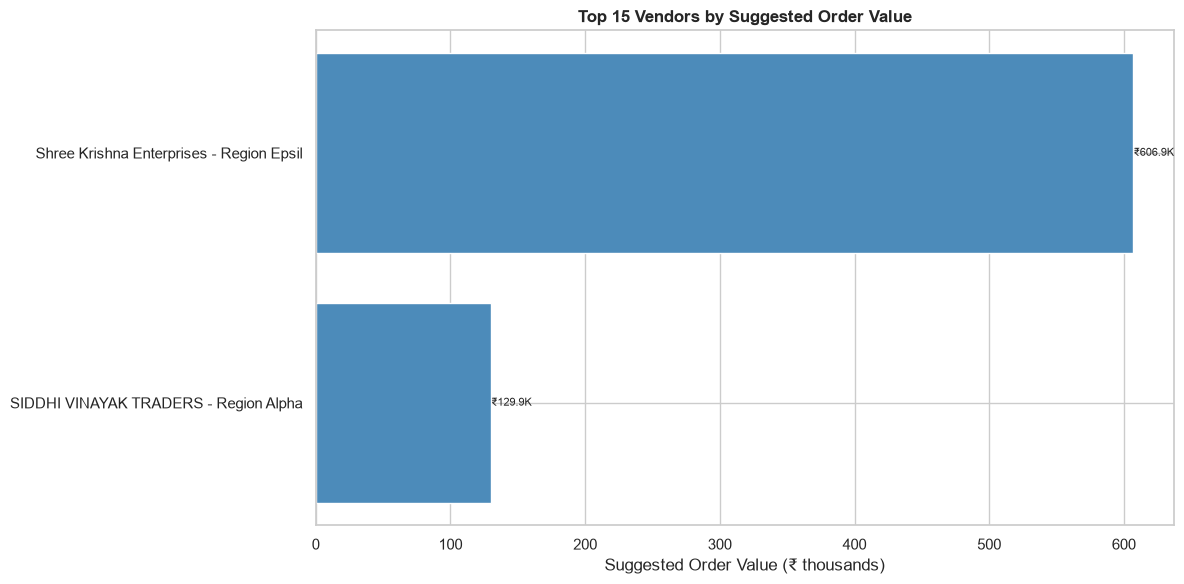

In [42]:
# ── 12d. Visualise vendor suggested value ───────────────────────────
top_v = vendor_summary[vendor_summary["total_suggested_value"] > 0].head(15)
fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#e07b54" if v > 0 else "#aaaaaa" for v in top_v["skus_mov_blocked"]]
bars = ax.barh(top_v["vendor_name"].str[:40][::-1],
               top_v["total_suggested_value"][::-1] / 1000,
               color="#4C8BBA")
ax.set_xlabel("Suggested Order Value (₹ thousands)")
ax.set_title("Top 15 Vendors by Suggested Order Value", fontweight="bold")
for bar, val in zip(bars, top_v["total_suggested_value"][::-1] / 1000):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            f"₹{val:,.1f}K", va="center", fontsize=8)
plt.tight_layout()
plt.show()


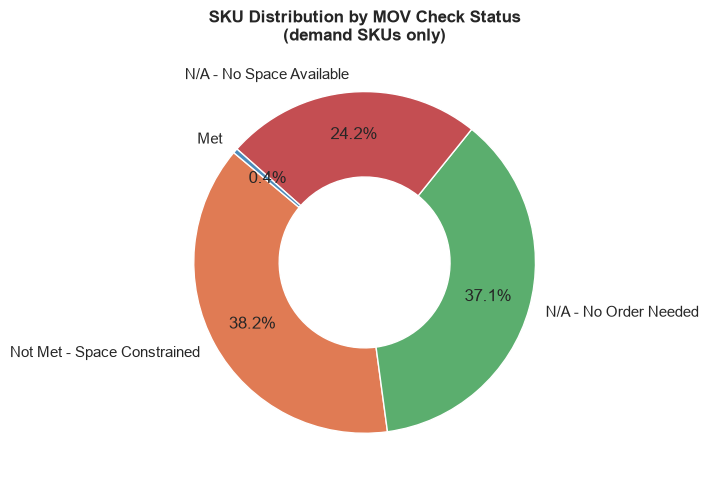

In [43]:
# ── 12e. MOV check donut ─────────────────────────────────────────────
demand_df = df[df["max_drr"] > 0]
vc = demand_df["mov_check"].value_counts()
color_map = {
    "N/A - No Order Needed"      : "#5bae6e",
    "Met"                        : "#4C8BBA",
    "Met (bumped to MOV)"        : "#a0c4f5",
    "Not Met - Space Constrained": "#e07b54",
    "N/A - No Space Available"   : "#c44e52",
}
colors = [color_map.get(k, "#aaaaaa") for k in vc.index]

fig, ax = plt.subplots(figsize=(7, 7))
wedges, texts, autotexts = ax.pie(
    vc.values, labels=vc.index, autopct="%1.1f%%",
    colors=colors, startangle=140,
    wedgeprops=dict(width=0.5), pctdistance=0.75
)
ax.set_title("SKU Distribution by MOV Check Status\n(demand SKUs only)", fontweight="bold")
plt.tight_layout()
plt.show()


In [44]:
# ── 12f. Save final output ───────────────────────────────────────────
# Drop internal helper columns before saving
save_cols_to_drop = [c for c in df.columns if c.startswith("_")
                     or c in ["inv_sellable","inv_contingency","inv_pending_putaway",
                              "inv_under_transfer","po_pipeline_units","po_arrived_units",
                              "po_leg_count","_inv_sum","_po_total_parsed",
                              "current_days_cover","space_utilisation_%",
                              "inv_parsed"]]
df_out = df.drop(columns=save_cols_to_drop, errors="ignore")

OUTPUT_PATH = "assignment_data_with_suggestions.csv"
df_out.to_csv(OUTPUT_PATH, index=False)
print(f"✅ Output saved → {OUTPUT_PATH}")
print(f"   Rows: {len(df_out):,}   Columns: {df_out.shape[1]}")
print()
print("=== Final output columns ===")
print(df_out[["jpin","final_suggestion","final_cases_suggestion",
              "final_value","final_tonnage","final_days_of_inventory","mov_check"]].head(10).to_string())


✅ Output saved → assignment_data_with_suggestions.csv
   Rows: 1,389   Columns: 36

=== Final output columns ===
        jpin  final_suggestion  final_cases_suggestion  final_value  final_tonnage  final_days_of_inventory                 mov_check
0  SKU-00786                 0                       0         0.00           0.00                      NaN           N/A - No Demand
1  SKU-00726                 0                       0         0.00           0.00                    23.70     N/A - No Order Needed
2  SKU-00846                 0                       0         0.00           0.00                    16.00     N/A - No Order Needed
3  SKU-00352                 0                       0         0.00           0.00                     8.50  N/A - No Space Available
4  SKU-00725                 0                       0         0.00           0.00                    19.30     N/A - No Order Needed
5  SKU-00780                 0                       0         0.00           0.00 

---
## Summary of Assumptions & Design Decisions

| # | Decision | Rationale |
|---|----------|-----------|
| 1 | `net_position = current_inventory + po_arrived_units + po_pipeline_units` | POs landing ≤ suggestion date are treated as received; true pipeline is in-transit only |
| 2 | `target = max(inv_norm, safety_stock) × max_drr` | Safety stock is a hard floor; inv_norm is the goal — take the higher of the two |
| 3 | Round UP for raw order, DOWN for space cap | Ensures we always request whole cases but never violate physical space ceiling |
| 4 | MOV checked per-SKU row, bump in case increments | Per-row evaluation; if space can't cover MOV, suggestion is zeroed + flagged (realistic: per-row is conservative; in production MOV is typically consolidated per vendor PO) |
| 5 | `current_inventory` is the authoritative on-hand figure | Breakup JSON sum ≠ current_inventory in 262 rows (under_transfer counted in total); warehouse system total wins |
| 6 | `sales_band` nulls → `"Unknown"` | 167 rows have no band; treated as a separate segment rather than imputed |
| 7 | `deadweight = 0` rows → `final_tonnage = 0` | Weight data unavailable; tonnage not blocked, just zero |
